<a href="https://colab.research.google.com/github/o-semenkova/ml_home_tasks/blob/main/Mid_term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в банку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Зчитуємо дані з Google Drive
raw_dataset = pd.read_csv("drive/MyDrive/colab_notebooks/machine-learning-by-hanna-pylieva/midterm/data/bank-additional-full.csv", sep=";")

In [4]:
# Огляд декількох записів з датафрейму
raw_dataset.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [5]:
raw_dataset.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
raw_dataset.shape

(41188, 21)

**Датасет має 21 стовпець та 41 188 строк, а також бачимо, що пропущених значень немає**

In [7]:
raw_dataset.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


**Аналіз описових статистик:**

**age** — середній вік клієнта ~40 років, розподіл досить типовий (std=10.4), діапазон від 17 до 98. Медіана (38) трохи нижче середнього — легка правостороння асиметрія, є старші клієнти, які "тягнуть" середнє вгору. В цілому нічого аномального.

**duration** — тривалість дзвінка, середня ~258 сек (~4.3 хв), але std майже дорівнює mean (259), що говорить про дуже широкий розкид. Є значення 0 (дзвінок не відбувся) і максимум 4918 сек (~82 хв). Розподіл явно правосторонній (медіана 180, набагато менше mean). Як зазначено в описі задачі — цю змінну не варто включати у фінальну модель, бо вона відома лише після дзвінка.

**campaign** — кількість контактів у поточній кампанії. Медіана = 2, mean = 2.57, але max = 56 — є клієнти, яким дзвонили дуже багато разів. Це потенційні outliers. 75-й перцентиль лише 3, тобто основна маса — 1–3 дзвінки, а хвіст дуже довгий.

**pdays** — дні від попереднього контакту. Медіана і 25-й перцентиль = 999, що означає, що більшість клієнтів не контактувались у попередній кампанії. Значення 999 — це фактично "не було контакту", а не реальна кількість днів. Цю змінну варто перетворити, наприклад, зробити бінарну ознаку "чи був попередній контакт" (pdays != 999).

**previous** — кількість контактів до поточної кампанії. Mean = 0.17, 75-й перцентиль = 0, max = 7. Тобто переважна більшість клієнтів раніше не контактувались (узгоджується з pdays). Дуже розріджена змінна.

**emp.var.rate** — темп зміни зайнятості. Діапазон від -3.4 до 1.4, медіана 1.1, тобто більшість спостережень припадає на період позитивної динаміки зайнятості. Це макроекономічний показник — однаковий для всіх клієнтів у конкретний період.

**cons.price.idx** — індекс споживчих цін. Дуже вузький діапазон (92.2–94.77), std = 0.58. Також макропоказник. Може бути корисний як індикатор економічного контексту кампанії.

**cons.conf.idx** — індекс довіри споживачів. Усі значення від'ємні (від -50.8 до -26.9), що типово для цього індексу. Середнє = -40.5. Теж макрозмінна.
euribor3m — ставка Euribor 3 місяці. Від 0.63 до 5.04, медіана 4.86 — тобто розподіл зміщений вліво, більшість спостережень при високій ставці, але є період низьких ставок. Сильно корелюватиме з іншими макрозмінними.

**nr.employed** — кількість працевлаштованих. Вузький діапазон (4963–5228), медіана 5191. Також макрозмінна, ймовірно високо корельована з emp.var.rate та euribor3m.

**Ключові висновки для подальшої роботи:**


*   Макрозмінні (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) будуть сильно корельовані між собою — варто це перевірити і, можливо, прибрати частину.
*   pdays потребує спеціальної обробки (999 — не число, а маркер відсутності контакту).
*   campaign має outliers у правому хвості.


In [8]:
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

nr.employed      -0.35
euribor3m        -0.31
emp.var.rate     -0.30
cons.price.idx   -0.14
cons.conf.idx     0.05
Name: y_num, dtype: float64


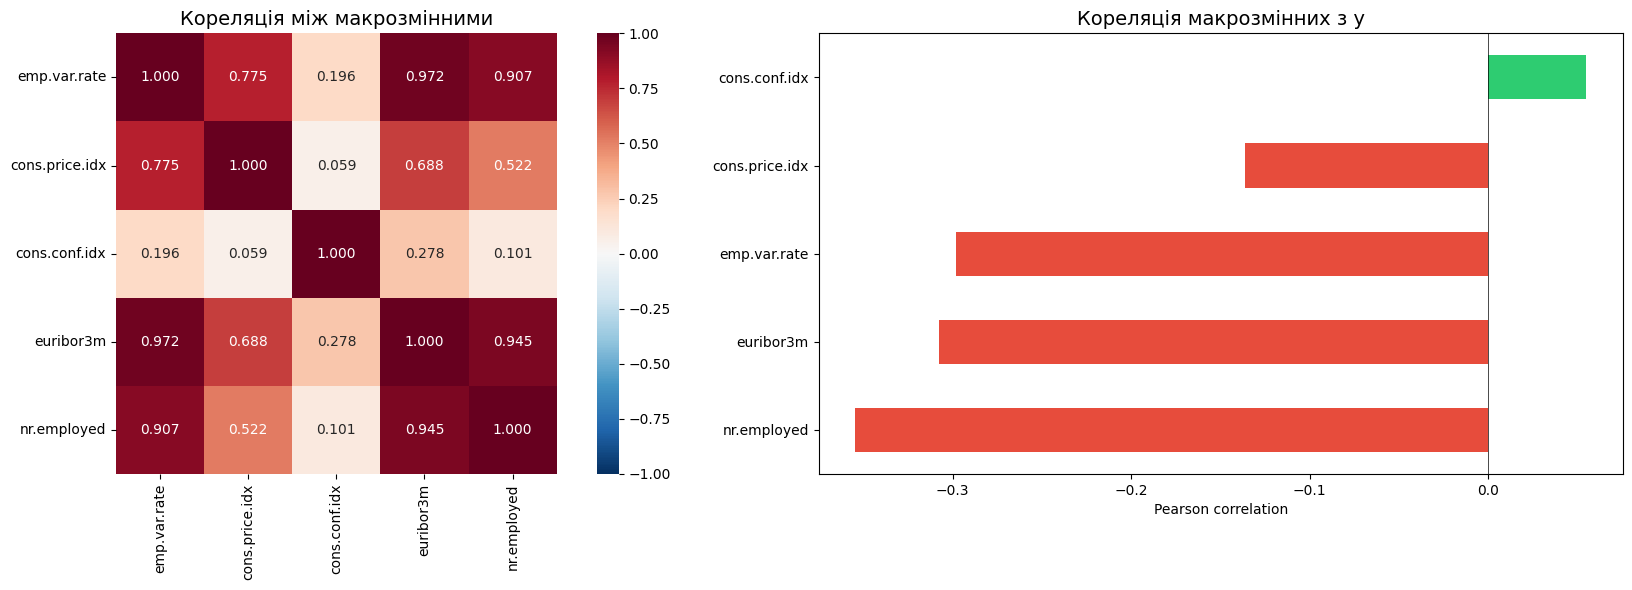

In [9]:
# КОРЕЛЯЦІЙНА МАТРИЦЯ (макрозмінні між собою) та КОРЕЛЯЦІЯ З ЦІЛЬОВОЮ ЗМІННОЮ y
corr_macro = raw_dataset[macro_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(corr_macro, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title('Кореляція між макрозмінними', fontsize=14)
raw_dataset['y_num'] = (raw_dataset['y'] == 'yes').astype(int)
corr_with_y = raw_dataset[macro_cols + ['y_num']].corr()['y_num'].drop('y_num').sort_values()
print(corr_with_y.round(4))

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_y.values]
corr_with_y.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Кореляція макрозмінних з y', fontsize=14)
axes[1].set_xlabel('Pearson correlation')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('macro_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Що бачимо:**
Усі знаки від'ємні (крім cons.conf.idx) — це означає, що коли економіка "на підйомі" (висока зайнятість, високі ставки, зростання цін), люди рідше підписують депозит. І навпаки — у період економічного спаду підписок більше. Це логічно: коли ставки падають і є невпевненість, люди шукають безпечні інструменти збереження грошей, як строковий депозит. А коли економіка росте — є привабливіші альтернативи для інвестицій.
**По кожній змінній:**


*   nr.employed (-0.35) — чим більше людей працевлаштовано (економіка процвітає), тим менше підписок. Найсильніший зв'язок із п'яти.
*   euribor3m (-0.31) — чим вища міжбанківська ставка, тим менше підписок. Це може здатися контрінтуїтивним (вища ставка = вищий % по депозиту), але тут ставка — індикатор загального стану економіки, а не безпосередньо ставка по депозиту.
*   emp.var.rate (-0.30) — чим швидше зростає зайнятість, тим менше підписок. Фактично дублює nr.employed (кореляція між ними 0.91).
*   cons.price.idx (-0.14) — слабкий зв'язок. Зростання цін трохи зменшує ймовірність підписки, але ефект невеликий.

*   cons.conf.idx (+0.05) — майже нульова кореляція. Індекс довіри споживачів практично не пов'язаний з рішенням про депозит лінійно. Але ця змінна все ж може бути корисною: вона несе інформацію, яку інші чотири не дублюють

**Важливе застереження:** кореляції тут досить помірні (максимум 0.35). Це означає, що макрозмінні самі по собі не є потужними предикторами — вони задають "фон", на якому працюють інші ознаки (тип контакту, результат попередньої кампанії, характеристики клієнта). У моделі вони будуть корисні в комбінації з іншими фічами, а не самостійно.

In [10]:

# VIF (Variance Inflation Factor)

print("VIF > 5  — помірна мультиколінеарність")
print("VIF > 10 — сильна мультиколінеарність\n")

X_macro = raw_dataset[macro_cols].dropna()
vif_data = pd.DataFrame({
    'Змінна': macro_cols,
    'VIF': [variance_inflation_factor(X_macro.values, i) for i in range(len(macro_cols))]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))


VIF > 5  — помірна мультиколінеарність
VIF > 10 — сильна мультиколінеарність

        Змінна      VIF
   nr.employed 25472.32
cons.price.idx 21362.91
     euribor3m   224.71
 cons.conf.idx   116.61
  emp.var.rate    28.70


In [11]:
# Ітеративне видалення за VIF (поріг = 10)

remaining = macro_cols.copy()
removed = []

while True:
    X_temp = raw_dataset[remaining].dropna()
    vifs = [variance_inflation_factor(X_temp.values, i) for i in range(len(remaining))]
    max_vif = max(vifs)
    max_idx = vifs.index(max_vif)

    if max_vif <= 10:
        break

    removed_var = remaining[max_idx]
    corr_y_val = abs(corr_with_y.get(removed_var, 0))
    print(f"Видаляємо: {removed_var:20s} (VIF={max_vif:.1f}, |corr з y|={corr_y_val:.4f})")
    removed.append(removed_var)
    remaining.remove(removed_var)

print(f"\nВидалені змінні:  {removed}")
print(f"Залишені змінні:  {remaining}")

print("\nФінальний VIF:")
raw_data_linear_models = raw_dataset[remaining].dropna()
for i, col in enumerate(remaining):
    vif = variance_inflation_factor(raw_data_linear_models.values, i)
    print(f"  {col:20s} VIF = {vif:.2f}")

Видаляємо: nr.employed          (VIF=25472.3, |corr з y|=0.3547)
Видаляємо: cons.price.idx       (VIF=243.3, |corr з y|=0.1362)
Видаляємо: euribor3m            (VIF=36.7, |corr з y|=0.3078)

Видалені змінні:  ['nr.employed', 'cons.price.idx', 'euribor3m']
Залишені змінні:  ['emp.var.rate', 'cons.conf.idx']

Фінальний VIF:
  emp.var.rate         VIF = 1.00
  cons.conf.idx        VIF = 1.00


Для лінійних моделей (Logistic Regression) краще залишити emp.var.rate + cons.conf.idx, тобто для них будемо використовувати датасет **raw_data_linear_models**.
А от для дерев і бустингу мультиколінеарність не є проблемою, тому там можна спокійно залишити всі п'ять — модель сама розбереться, тож тут будемо використовувати звичайний **raw_dataset**

In [12]:
numeric_cols = raw_dataset.select_dtypes(include='number').columns.tolist()
non_macro_numeric = [col for col in numeric_cols if col not in macro_cols]

In [26]:
# КОРЕЛЯЦІЙНА МАТРИЦЯ (усі числові змінні, окрім макрозмінних, між собою) та КОРЕЛЯЦІЯ З ЦІЛЬОВОЮ ЗМІННОЮ y
corr = raw_dataset[non_macro_numeric].corr()
print(corr)

           age  duration  campaign  pdays  previous  y_num
age       1.00     -0.00      0.00  -0.03      0.02   0.03
duration -0.00      1.00     -0.07  -0.05      0.02   0.41
campaign  0.00     -0.07      1.00   0.05     -0.08  -0.07
pdays    -0.03     -0.05      0.05   1.00     -0.59  -0.32
previous  0.02      0.02     -0.08  -0.59      1.00   0.23
y_num     0.03      0.41     -0.07  -0.32      0.23   1.00


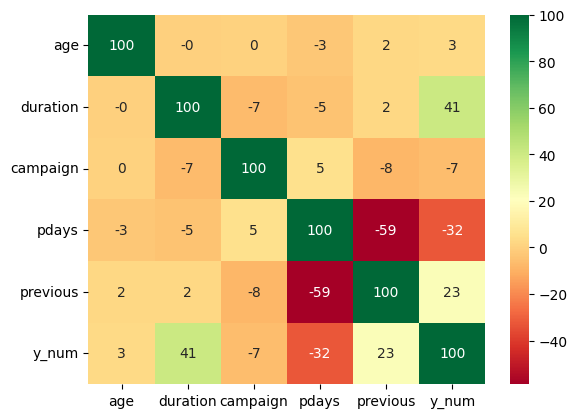

In [27]:
sns.heatmap(corr*100, annot = True, cmap = "RdYlGn", cbar = True, fmt='.0f')
plt.show()


**Що бачимо тут:**


*   **duration (0.41 з y)** — найсильніший предиктор серед числових змінних. Чим довше тривав дзвінок, тим вища ймовірність підписки. Це логічно — якщо клієнт зацікавлений, він довше розмовляє. Але цю змінну не можна використовувати у фінальній моделі, бо вона відома лише після дзвінка. Тож можна буде іі використати для перевірки результатів.
*   **pdays (-0.32 з y)** — другий за силою зв'язок. Від'ємна кореляція тут "обманлива" через кодування 999. Фактично це означає: клієнти, яких контактували в попередній кампанії (pdays < 999), значно частіше підписують депозит. Це підтверджує ідею створити бінарну ознаку was_contacted_before = (pdays != 999).
*   **previous (0.23 з y)** — чим більше контактів було до цієї кампанії, тим вища ймовірність підписки. Узгоджується з pdays — "теплі" клієнти конвертуються краще.
*   **campaign (-0.07 з y)** — слабкий від'ємний зв'язок. Чим більше разів дзвонили в поточній кампанії, тим менша ймовірність підписки. Логічно: якщо клієнт не погодився з першого-другого разу, кожен наступний дзвінок все менш ефективний.
*   **age (0.03 з y)** — практично нульова лінійна кореляція. Але це не означає, що вік не важливий — зв'язок може бути нелінійним (наприклад, молоді студенти і пенсіонери підписують частіше, а середній вік — рідше). Це варто перевірити через візуалізацію або дерева рішень.
*   Цікавий зв'язок pdays ↔ previous (-0.59) — помітна кореляція між собою. Це логічно: якщо pdays = 999 (не було контакту), то і previous = 0. Вони несуть частково однакову інформацію — "чи є в клієнта історія взаємодії з банком".

####**Головний висновок:** після виключення duration, найцінніші числові ознаки — це pdays і previous (історія попередніх контактів). Age і campaign мають слабкий лінійний зв'язок, але можуть бути корисними в нелінійних моделях (дерева, бустинг).

Тож побудуємо візуалізацію для age:

/tmp/ipykernel_331/1066866239.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = raw_dataset.groupby('age_group')['y_num'].agg(['mean', 'count']).reset_index()


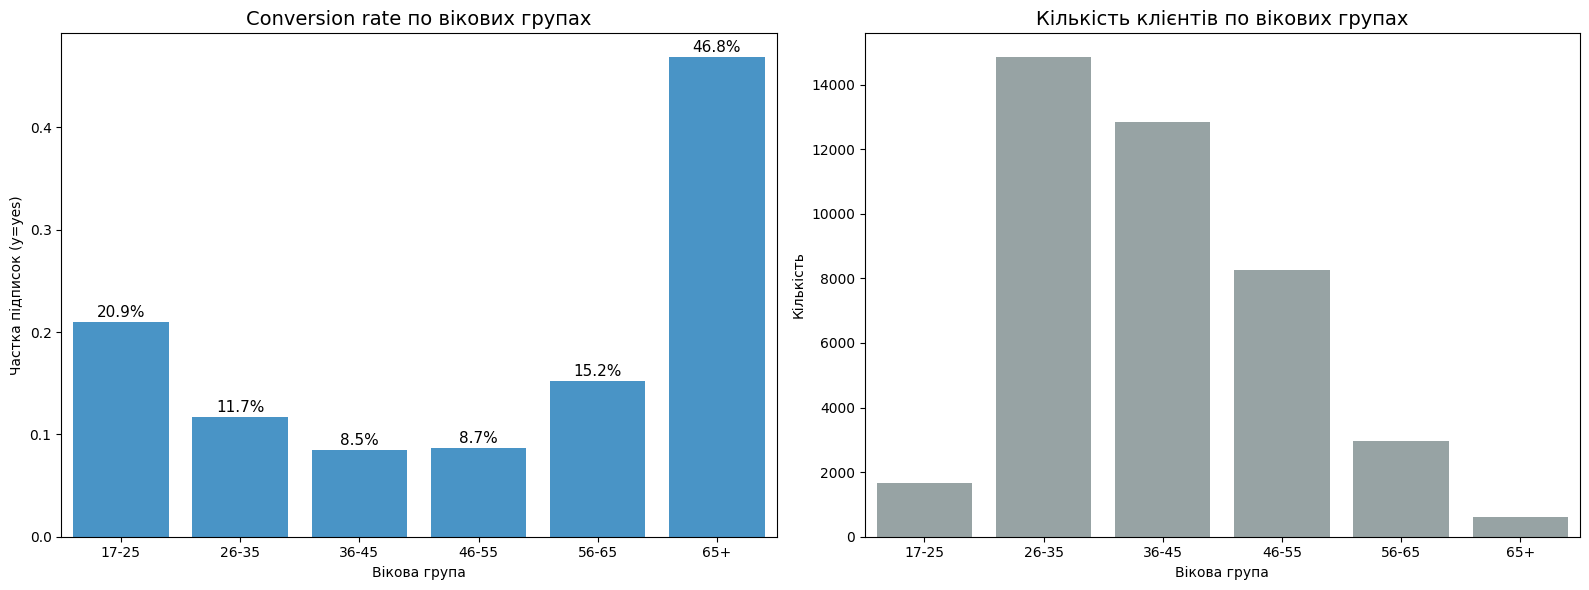

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Створюємо вікові групи
raw_dataset['age_group'] = pd.cut(raw_dataset['age'],
                                   bins=[0, 25, 35, 45, 55, 65, 100],
                                   labels=['17-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Рахуємо conversion rate по групах
age_stats = raw_dataset.groupby('age_group')['y_num'].agg(['mean', 'count']).reset_index()
age_stats.columns = ['age_group', 'conversion_rate', 'count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Conversion rate по вікових групах
sns.barplot(data=age_stats, x='age_group', y='conversion_rate', ax=axes[0], color='#3498db')
axes[0].set_title('Conversion rate по вікових групах', fontsize=14)
axes[0].set_ylabel('Частка підписок (y=yes)')
axes[0].set_xlabel('Вікова група')
for i, row in age_stats.iterrows():
    axes[0].text(i, row['conversion_rate'] + 0.005, f"{row['conversion_rate']:.1%}",
                ha='center', fontsize=11)

# 2. Кількість клієнтів у кожній групі (для контексту)
sns.barplot(data=age_stats, x='age_group', y='count', ax=axes[1], color='#95a5a6')
axes[1].set_title('Кількість клієнтів по вікових групах', fontsize=14)
axes[1].set_ylabel('Кількість')
axes[1].set_xlabel('Вікова група')

plt.tight_layout()
plt.show()

Дійсно бачимо U-подібну залежність (тобто молодь (17-25) та люди пенсійного віку (65+) ніби частіше беруть депозит), але на правому графіку також бачимо відносно невелику кількість людей 65+, тож:

Conversion rate (лівий графік) підтверджує U-подібний патерн, але з важливим нюансом — він не симетричний, а скоріше J-подібний:

65+ — рекордні 46.8%, майже кожен другий підписує депозит
17-25 — 20.9%, теж значно вище середнього
56-65 — 15.2%, починає зростати
26-35 і 36-55 — "дно" конверсії (8.5–11.7%)

Правий графік (кількість) додає критичний контекст:

65+ з конверсією 46.8% — це лише ~500 клієнтів. Конверсія велика, але вибірка маленька, і банк фізично не зможе на них побудувати масову стратегію.

26-35 і 36-45 — основна маса клієнтів (~15 000 і ~13 000), але конверсія найнижча. Саме тут банк "втрачає" найбільше — навіть невелике покращення конверсії в цих групах дасть більше підписок у абсолютних числах, ніж висока конверсія серед пенсіонерів.

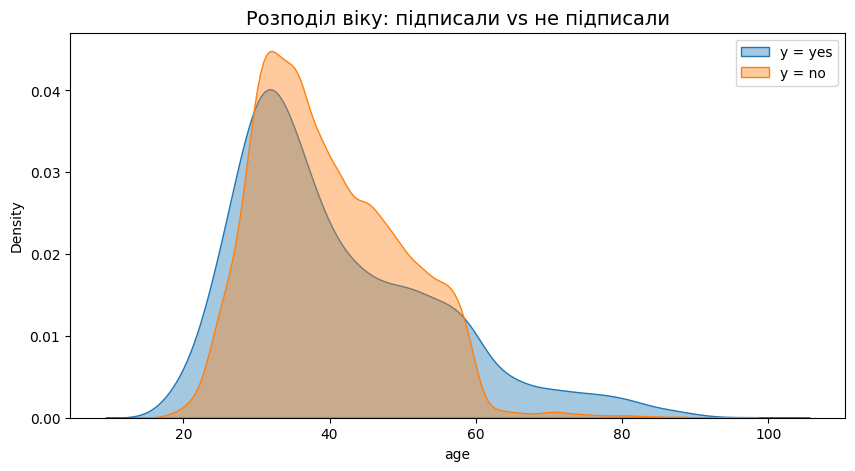

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=raw_dataset[raw_dataset['y'] == 'yes'], x='age', label='y = yes', fill=True, alpha=0.4)
sns.kdeplot(data=raw_dataset[raw_dataset['y'] == 'no'], x='age', label='y = no', fill=True, alpha=0.4)
ax.set_title('Розподіл віку: підписали vs не підписали', fontsize=14)
ax.legend()
plt.show()

Графік підтверджує гіпотезу про нелінійний зв'язок віку з підпискою. Ось що видно:
**Молодь (~20–30 років)** — синя крива (y=yes) стартує раніше і піднімається швидше, ніж оранжева (y=no). Тобто серед молодих клієнтів частка підписок відносно вища. Це можуть бути студенти, які тільки починають відкладати гроші.

**Середній вік (~35–55)** — оранжева крива домінує над синьою. Це основна маса клієнтів, і саме вони найрідше підписують депозит. Ймовірно, у цьому віці люди мають іпотеки, витрати на сім'ю, і депозит їм менш цікавий.

**Старший вік (~60+)** — синій "хвіст" тягнеться далі і повільніше спадає, ніж оранжевий. Тобто серед пенсіонерів відносна частка підписок знову зростає. Це логічно — люди на пенсії шукають безпечне збереження коштів.

####**Головний висновок:** зв'язок віку з підпискою — U-подібний (молодь і пенсіонери підписують частіше, середній вік — рідше). Саме тому Pearson кореляція показала майже 0 — вона бачить лише лінійний зв'язок, а тут два ефекти "компенсують" один одного. Для моделі це означає, що дерева і бустинг підхоплять цей нелінійний патерн автоматично, а для логістичної регресії варто створити додаткову ознаку, наприклад поліноміальну (age²) або бінарну (is_young, is_retired)

# Сумарний висновок по EDA числових змінних

**Загальна картина**
Датасет містить 41 188 записів і 10 числових змінних. Серед них чітко виділяються дві групи:
 - 5 макроекономічних показників (які описують зовнішнє середовище)
 - 5 клієнтських/кампанійних змінних (які описують самого клієнта та взаємодію з ним).

**Що ми виявили:**
 - Макрозмінні сильно корельовані між собою (VIF до 25 000). Для лінійних моделей після ітеративного VIF-видалення залишаємо лише emp.var.rate і cons.conf.idx.

 - Для дерев і бустингу можна залишити всі п'ять. Усі макрозмінні (крім cons.conf.idx) від'ємно корелюють з y — в період економічного спаду люди частіше підписують депозити.

 - duration (corr = 0.41) — найсильніший предиктор, але його не можна використовувати у фінальній моделі через data leakage.

 - pdays і previous — найцінніші клієнтські ознаки після виключення duration. Наявність попереднього контакту суттєво підвищує ймовірність підписки.

 - age — лінійна кореляція майже нульова (0.03), але виявлено сильний нелінійний J-подібний зв'язок: конверсія 65+ = 46.8%, 17-25 = 20.9%, а "дно" — 36-45 років (8.5%).

 - campaign — слабкий від'ємний зв'язок з y (-0.07), має довгий правий хвіст (max=56 при медіані=2).

**Трансформаційні операції зі змінними**

**Видалити:**

 - duration — data leakage, відома лише після дзвінка

 - Для логістичної регресії/kNN: nr.employed, cons.price.idx, euribor3m — через мультиколінеарність

**Трансформувати:**

 - pdays — значення 999 це не число, а маркер "не було контакту". Створити бінарну ознаку was_contacted_before = (pdays != 999), а для тих, хто контактувався, залишити оригінальне значення pdays або прологарифмувати

 - campaign — обрізати outliers або застосувати log-трансформацію, бо розподіл сильно скошений

**Додати нові ознаки:**

 - was_contacted_before = (pdays != 999) — однозначно корисна, бо перетворює "магічне" 999 на зрозумілий сигнал

 - age_squared — тільки для логістичної регресії

**Залишити без змін:**

 - age, previous — використовувати як є
Для дерев/бустингу: всі 5 макрозмінних можна залишити

In [31]:
# ============================================
# Огляд категоріальних змінних
# ============================================
cat_cols = raw_dataset.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')
print(f"Категоріальних змінних: {len(cat_cols)}")
print(f"Список: {cat_cols}")
print(f"\nЦільова змінна y:")
print(raw_dataset['y'].value_counts())
print(f"\nБаланс класів: {raw_dataset['y'].value_counts(normalize=True).round(3)}")

Категоріальних змінних: 10
Список: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Цільова змінна y:
y
no     36548
yes     4640
Name: count, dtype: int64

Баланс класів: y
no    0.89
yes   0.11
Name: proportion, dtype: float64


Тож маємо 10 категоріальних змінних, і датасет дуже незбалансований (~88.7% "no" і ~11.3% "yes").

In [32]:
# ============================================
# Скільки унікальних значень і unknown
# ============================================
summary = pd.DataFrame({
    'Унікальних': [raw_dataset[col].nunique() for col in cat_cols],
    'Unknown': [(raw_dataset[col] == 'unknown').sum() for col in cat_cols],
    'Unknown %': [(raw_dataset[col] == 'unknown').sum() / len(raw_dataset) * 100 for col in cat_cols]
}, index=cat_cols).round(1)

print(summary)

             Унікальних  Unknown  Unknown %
job                  12      330       0.80
marital               4       80       0.20
education             8     1731       4.20
default               3     8597      20.90
housing               3      990       2.40
loan                  3      990       2.40
contact               2        0       0.00
month                10        0       0.00
day_of_week           5        0       0.00
poutcome              3        0       0.00


Тут бачимо, що default має 20.9% unknown — це важливий сигнал.

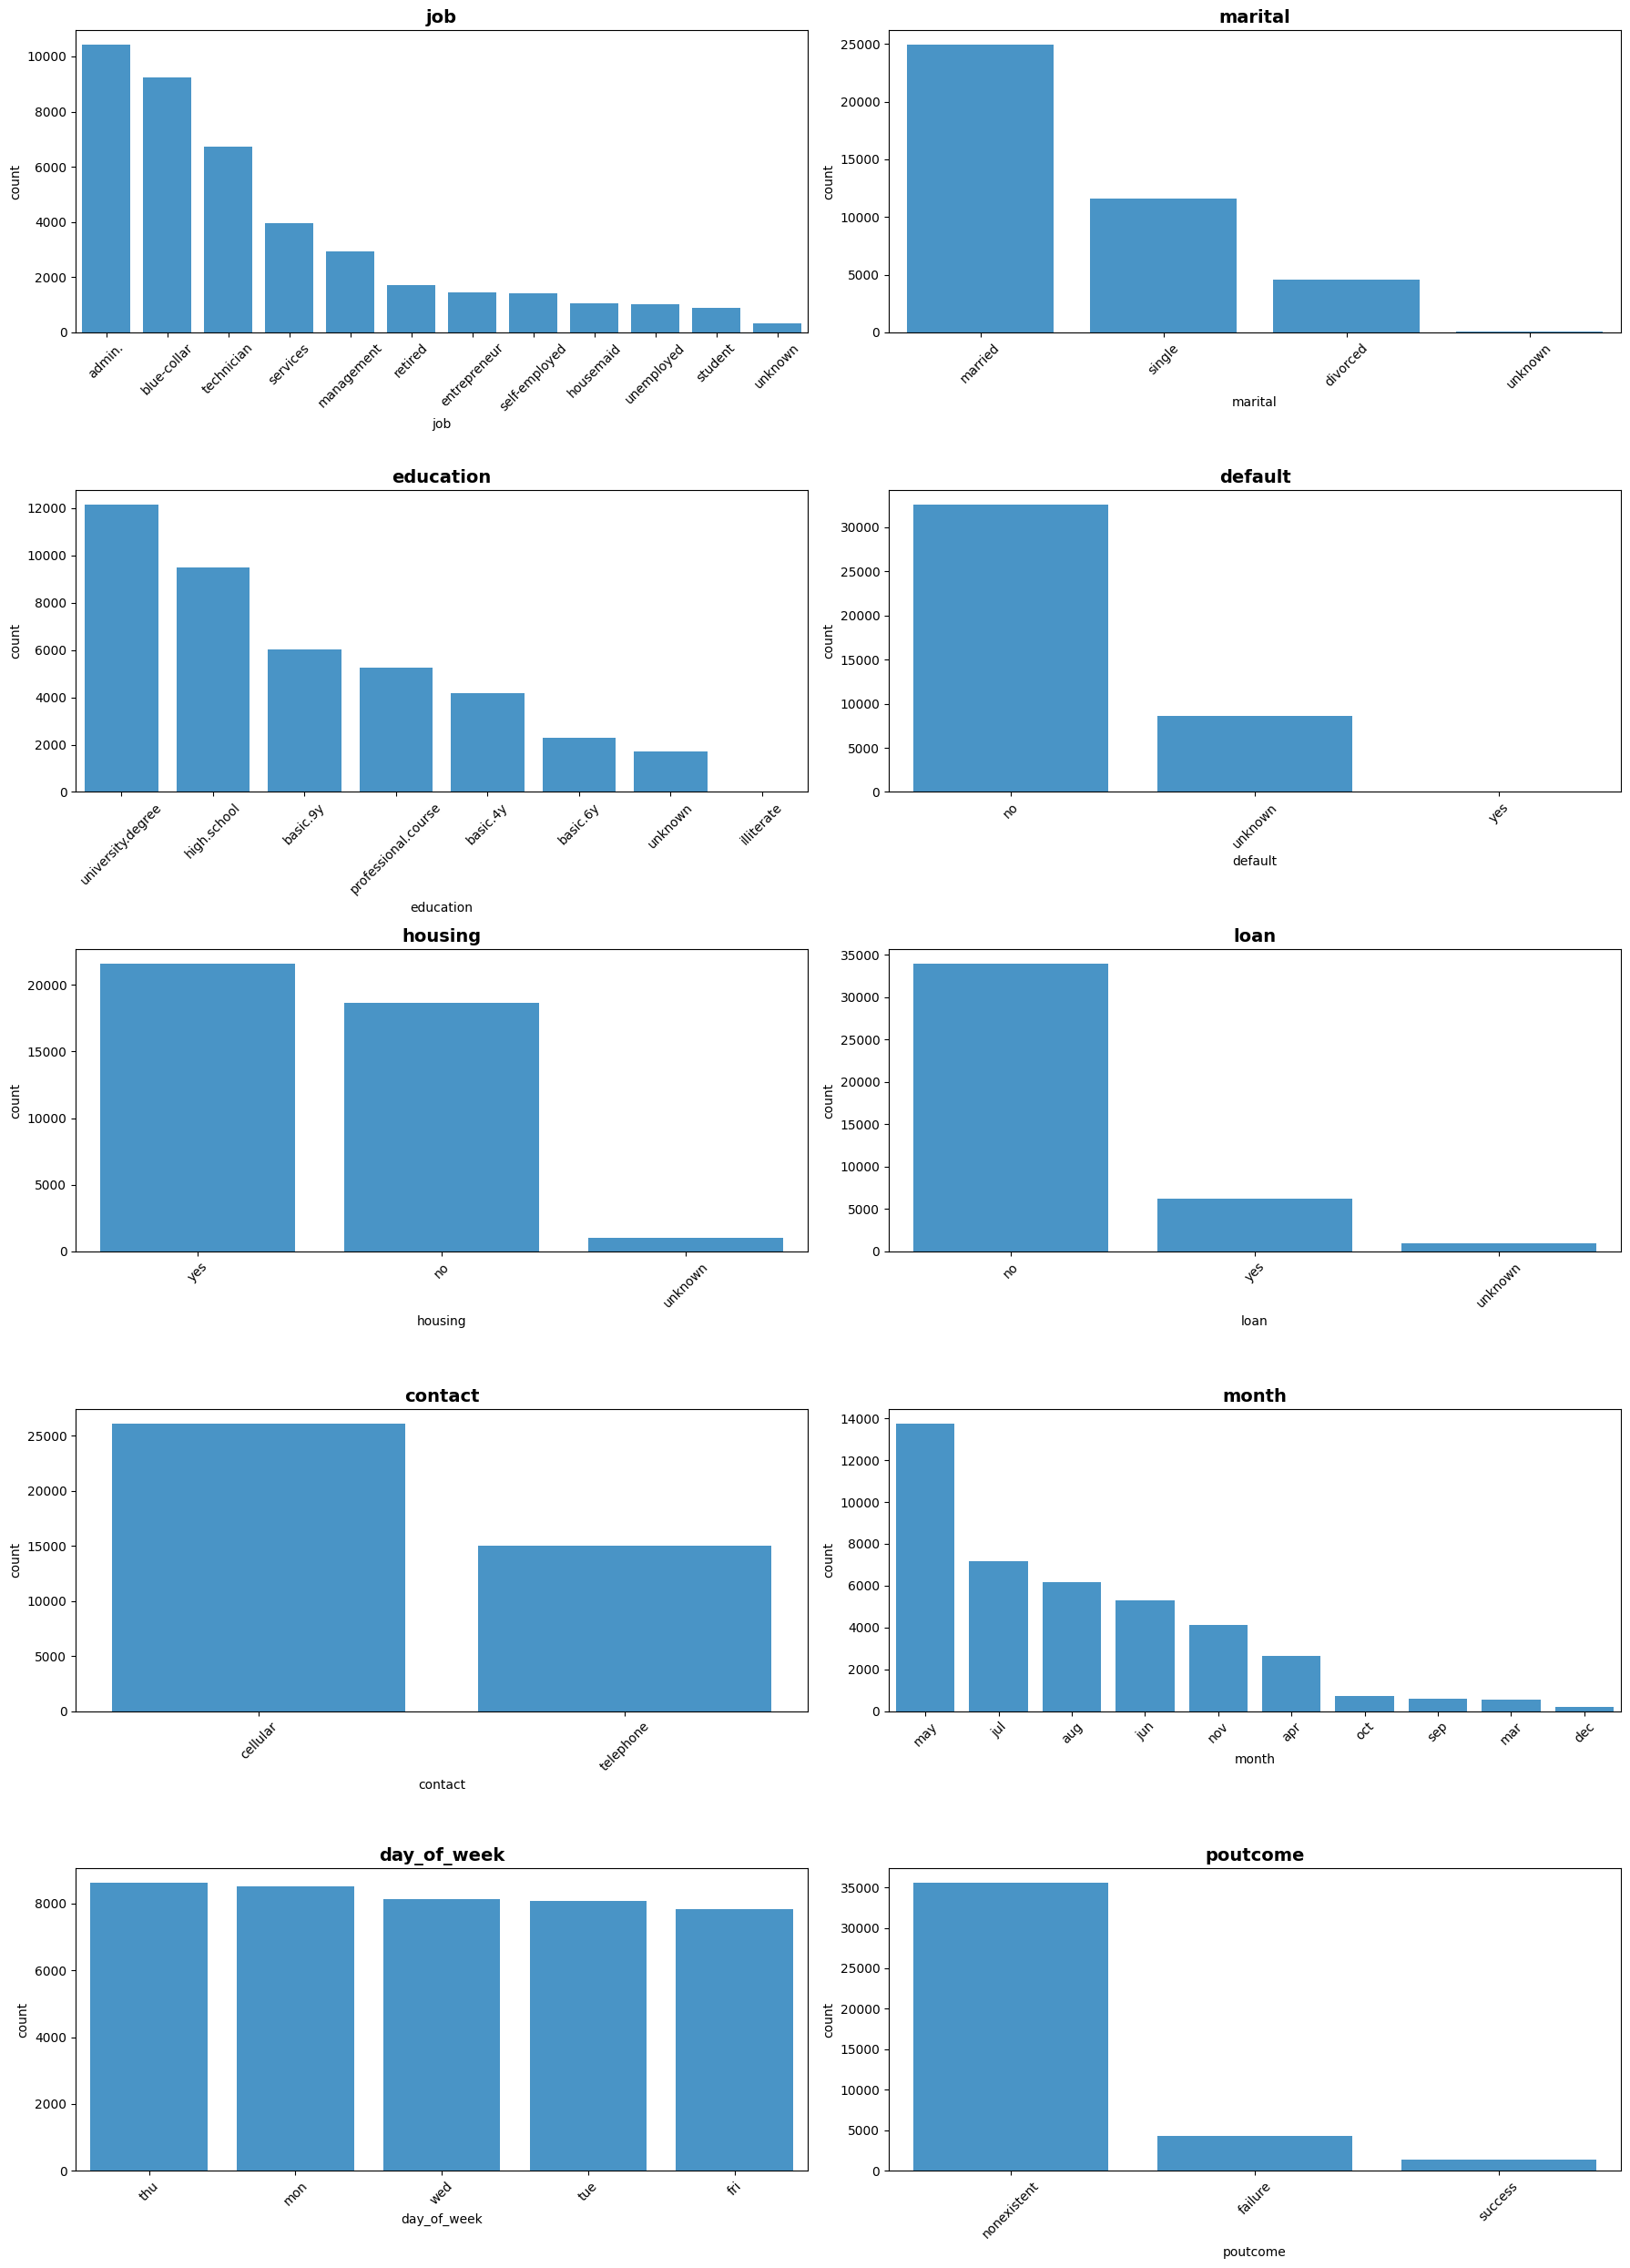

In [33]:
# ============================================
# Розподіл кожної змінної (countplot) - подивимось як розподілені категорії: де є домінантні класи, де є рідкісні.
# ============================================
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = raw_dataset[col].value_counts().index
    sns.countplot(data=raw_dataset, x=col, order=order, ax=axes[i], color='#3498db')
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

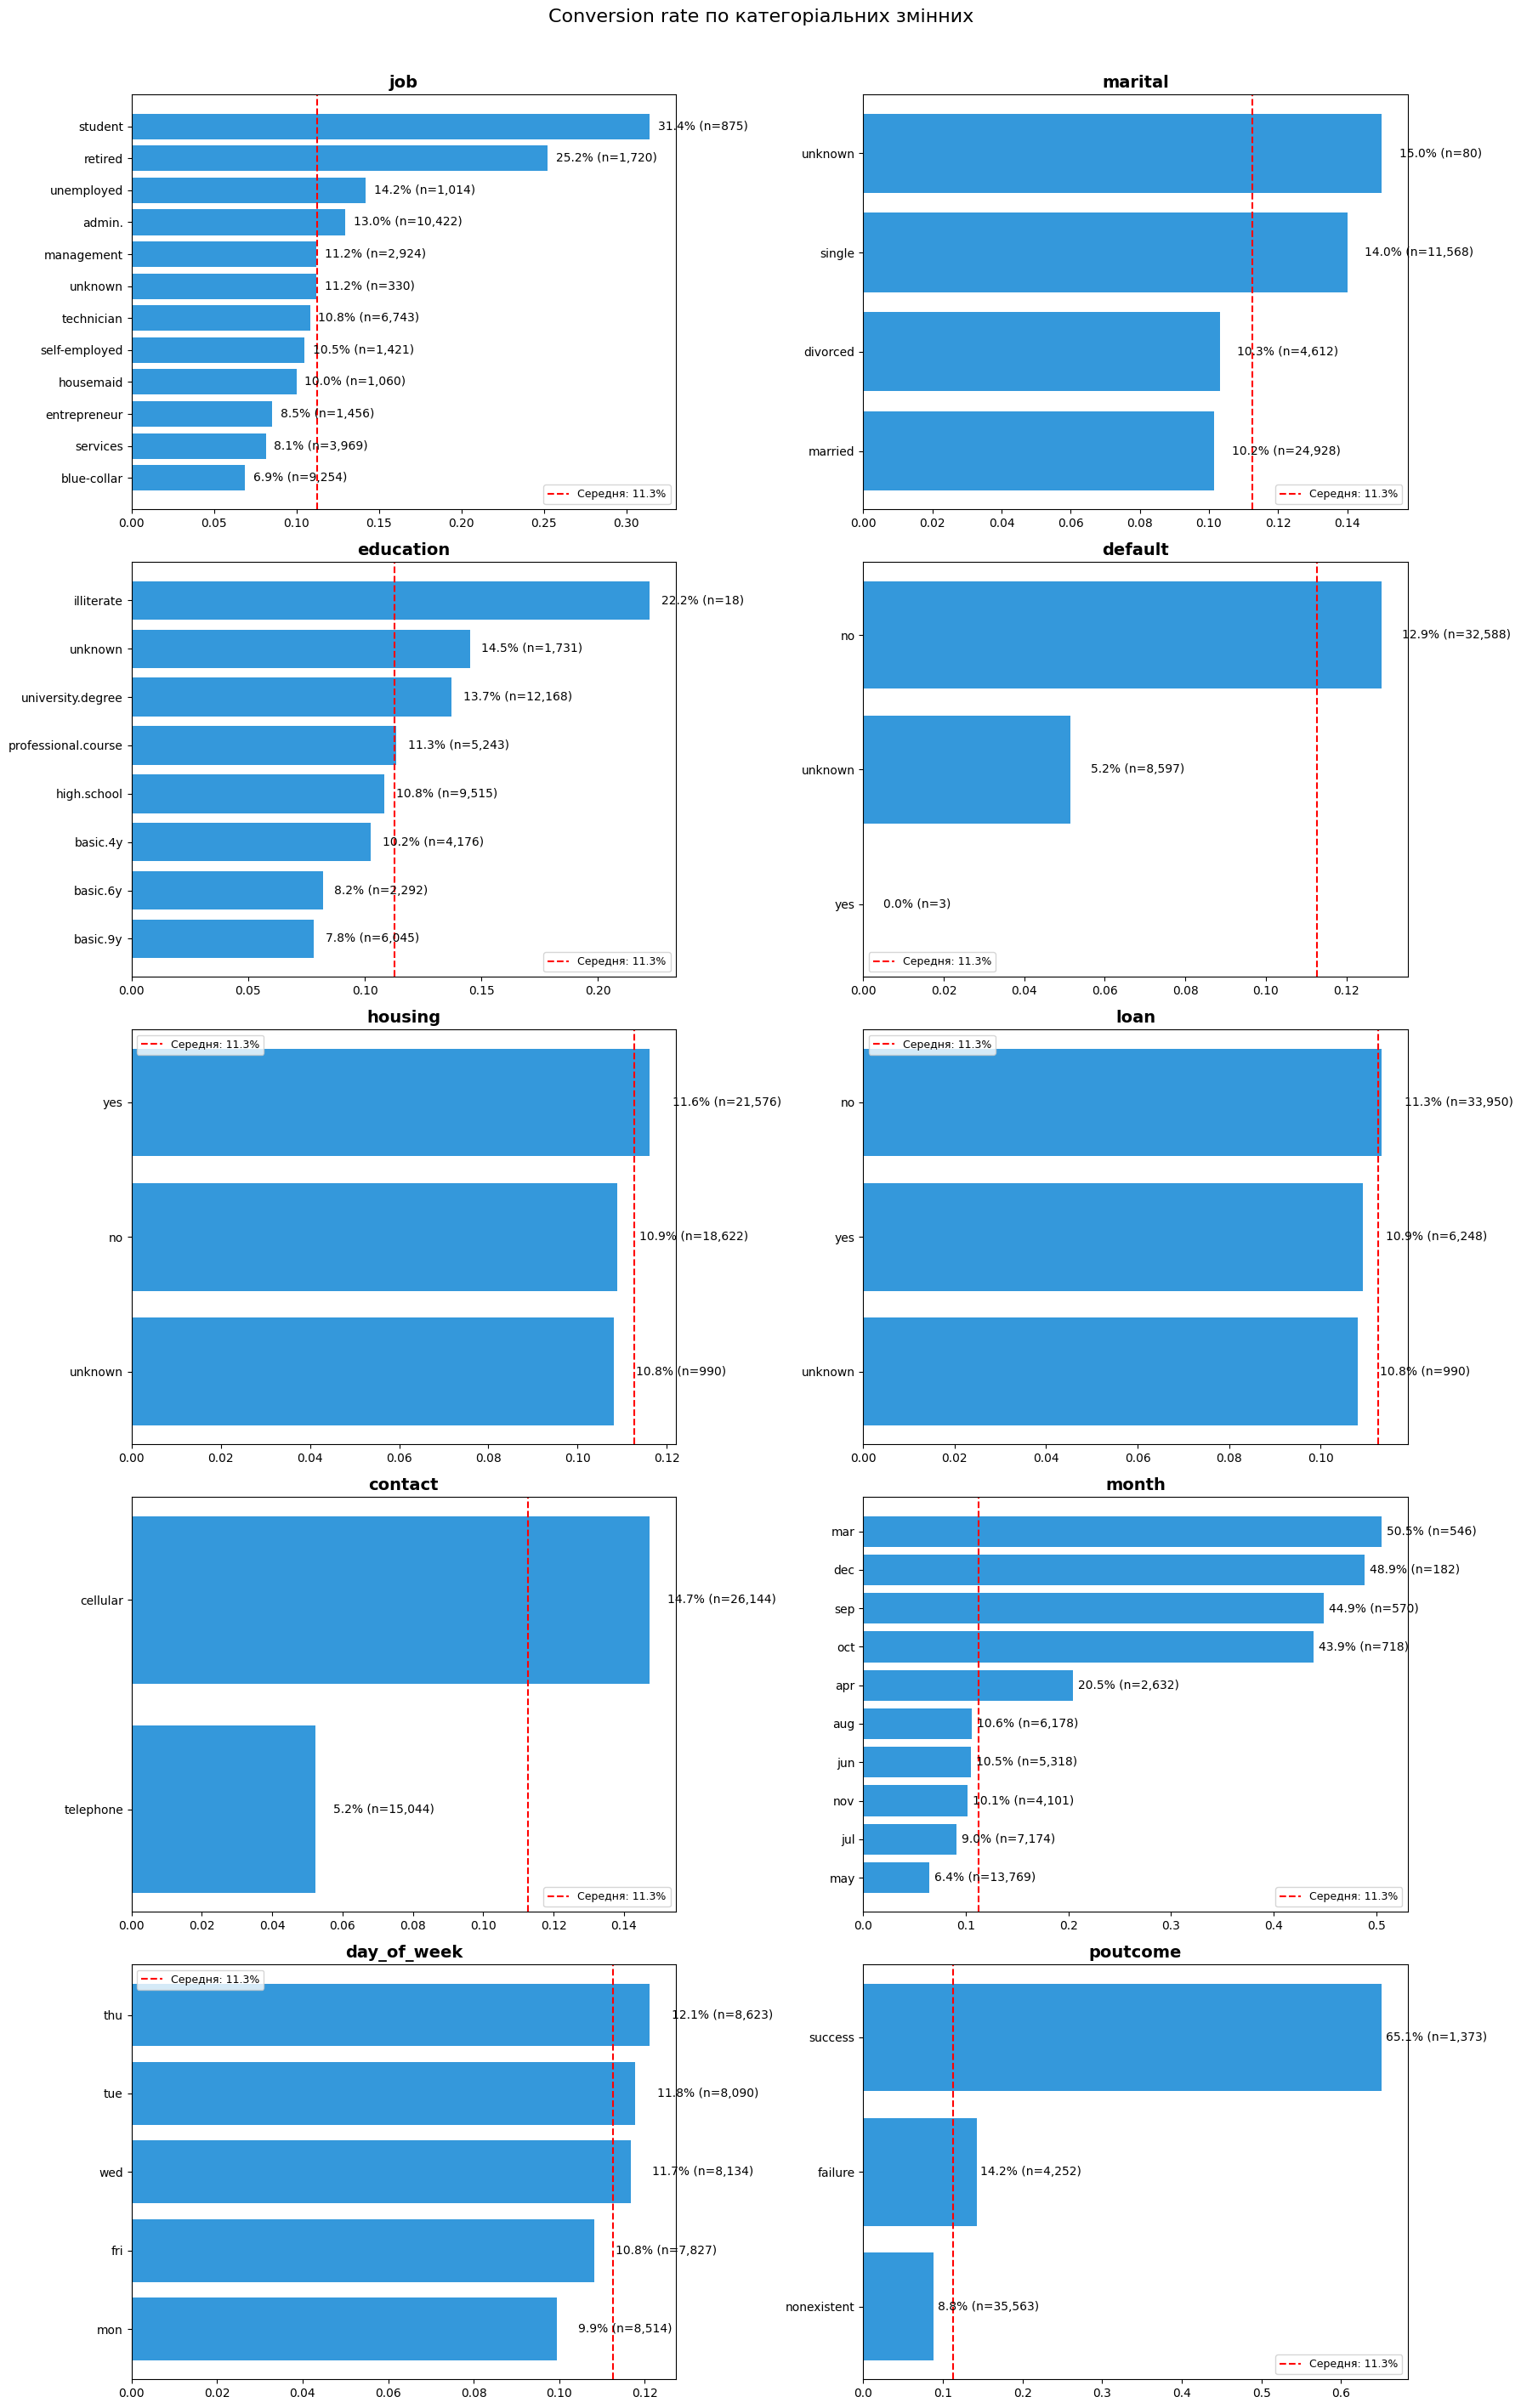

In [34]:
# ============================================
# Conversion rate по кожній змінній
# ============================================
raw_dataset['y_num'] = (raw_dataset['y'] == 'yes').astype(int)
avg_rate = raw_dataset['y_num'].mean()

fig, axes = plt.subplots(5, 2, figsize=(18, 28))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stats = raw_dataset.groupby(col)['y_num'].agg(['mean', 'count']).reset_index()
    stats.columns = [col, 'conv_rate', 'count']
    stats = stats.sort_values('conv_rate', ascending=True)

    ax = axes[i]
    ax.barh(stats[col], stats['conv_rate'], color='#3498db')
    ax.axvline(x=avg_rate, color='red', linestyle='--', label=f'Середня: {avg_rate:.1%}')

    for j, (_, row) in enumerate(stats.iterrows()):
        ax.text(row['conv_rate'] + 0.005, j,
                f"{row['conv_rate']:.1%} (n={row['count']:,})",
                va='center', fontsize=10)

    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Conversion rate по категоріальних змінних', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Conversion rate (коефіцієнт конверсії) — це просто частка тих, хто сказав "yes" у кожній групі.

Середня конверсія по всьому датасету — 11.3% (4 640 "yes" з 41 188). І коли ми бачимо, що якась група має конверсію значно вищу або нижчу за цю середню — це сигнал, що ознака впливає на рішення клієнта.

По суті, conversion rate — це те саме, що P(y=yes | група), тобто ймовірність підписки за умови належності до певної групи. Це гарний спосіб зрозуміти, як категоріальна змінна пов'язана з цільовою.

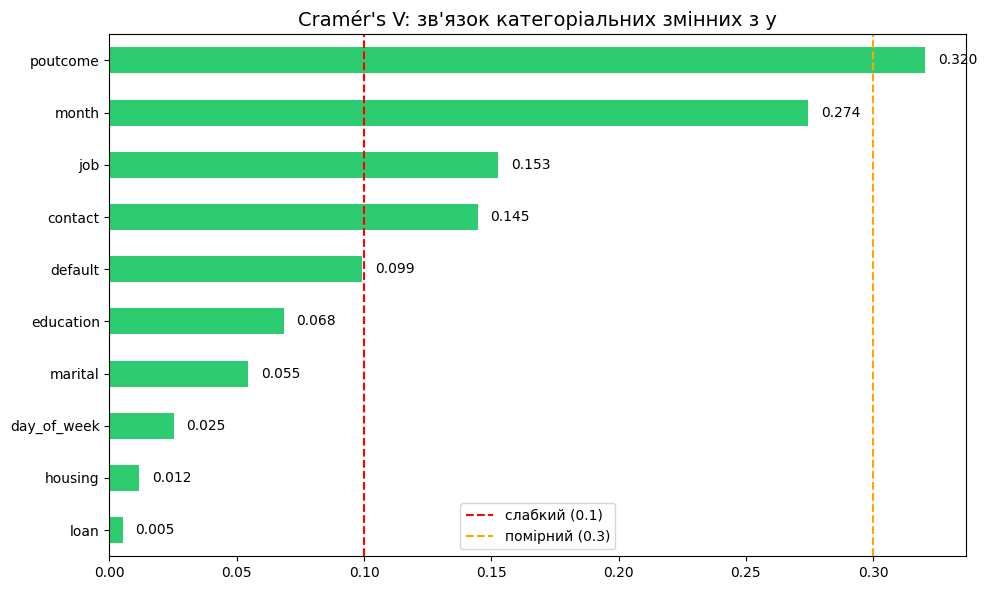

In [36]:
# ============================================
# Cramér's V — сила зв'язку з y - Цей графік дає "рейтинг" змінних за силою зв'язку з y.
# ============================================
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

cramers = {col: cramers_v(raw_dataset[col], raw_dataset['y']) for col in cat_cols}
cramers_df = pd.Series(cramers).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
cramers_df.plot(kind='barh', color='#2ecc71', ax=ax)
ax.axvline(x=0.1, color='red', linestyle='--', label='слабкий (0.1)')
ax.axvline(x=0.3, color='orange', linestyle='--', label='помірний (0.3)')
ax.set_title("Cramér's V: зв'язок категоріальних змінних з y", fontsize=14)
ax.legend()

for i, (idx, val) in enumerate(cramers_df.items()):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

Cramér's V ранжує всі категоріальні змінні за силою зв'язку з y за шкалою від 0 (зв'язку немає) до 1 (повний зв'язок):

**Сильний зв'язок (V > 0.3):**

**poutcome (≈0.33)** — єдина змінна з помірно-сильним зв'язком. Результат попередньої кампанії — найпотужніший категоріальний предиктор у датасеті.

**Слабкий, але помітний (V ≈ 0.1–0.15):**

**month (≈0.14)** — місяць контакту має значення, конверсія сильно залежить від періоду.
**contact (≈0.13)** — тип зв'язку (cellular vs telephone) помітно впливає.

**Слабкий зв'язок (V < 0.1):**

**job, education, default** — є окремі цікаві категорії всередині, але загальна сила зв'язку невелика.
**housing, loan, day_of_week, marital** — практично не пов'язані з y. Ці змінні самі по собі майже не допомагають відрізнити "yes" від "no".

**Висновок:** серед 10 категоріальних змінних лише 3 мають реальну предиктивну силу — poutcome, month і contact. Решта можуть бути корисними в комбінації з іншими ознаками (особливо в деревах), але самостійно вони слабкі.

In [38]:
# ============================================
# Детальний аналіз топ-змінних згідно графіка вище
# ============================================

# poutcome
print("=== poutcome ===")
print(raw_dataset.groupby('poutcome')['y_num'].agg(['mean', 'count']).round(3))

# month
print("\n=== month (відсортовано за конверсією) ===")
month_stats = raw_dataset.groupby('month')['y_num'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(month_stats.round(3))

# contact
print("\n=== contact ===")
print(raw_dataset.groupby('contact')['y_num'].agg(['mean', 'count']).round(3))

=== poutcome ===
             mean  count
poutcome                
failure      0.14   4252
nonexistent  0.09  35563
success      0.65   1373

=== month (відсортовано за конверсією) ===
       mean  count
month             
mar    0.51    546
dec    0.49    182
sep    0.45    570
oct    0.44    718
apr    0.20   2632
aug    0.11   6178
jun    0.10   5318
nov    0.10   4101
jul    0.09   7174
may    0.06  13769

=== contact ===
           mean  count
contact               
cellular   0.15  26144
telephone  0.05  15044


**poutcome — "сильна" ознака:**

 - success → конверсія 65.1%, тобто 2 з 3 клієнтів підписують. Але таких записів лише 1 373 (3.3% датасету).
 - failure → 14.2%, що все одно вище середньої (11.3%). Навіть невдалий попередній контакт — краще, ніж жодного.
 - nonexistent → 8.8%, нижче середньої. Це 86% датасету — клієнти без історії.

Якщо клієнт вже мав досвід взаємодії з банком, він з більшою ймовірністю погодиться. А якщо попередня кампанія для нього була успішною — він майже напевно погодиться знову. Це узгоджується з тим, що ми бачили по pdays і previous у числовому аналізі.

**month — великий розкид, але:**

 - "Успішні" місяці: mar (50.5%), dec (48.9%), sep (44.9%), oct (43.9%) — конверсія в 4–5 разів вища за середню.
 - "Невдалі" місяці: may (6.4%), jul (9.0%) — нижче середньої, і саме на них припадає найбільше дзвінків (may = 13 769).

Але: "успішні" місяці мають мало спостережень (mar=546, dec=182). Швидше за все, це не магія місяця, а те, що в ці періоди банк дзвонив більш цільовій аудиторії або макроекономічний контекст був сприятливіший. Ця змінна може частково дублювати інформацію з макрозмінних.

**contact — проста але ефективна ознака:**

 - cellular → 14.7% конверсії
 - telephone → 5.2%, втричі менше

Мобільний телефон — це більш "особистий" канал, клієнт швидше відповідає і більш залучений у розмову. Telephone (стаціонарний) може означати, що банк не має мобільного номера клієнта, що вже само по собі свідчить про слабший зв'язок з клієнтом.

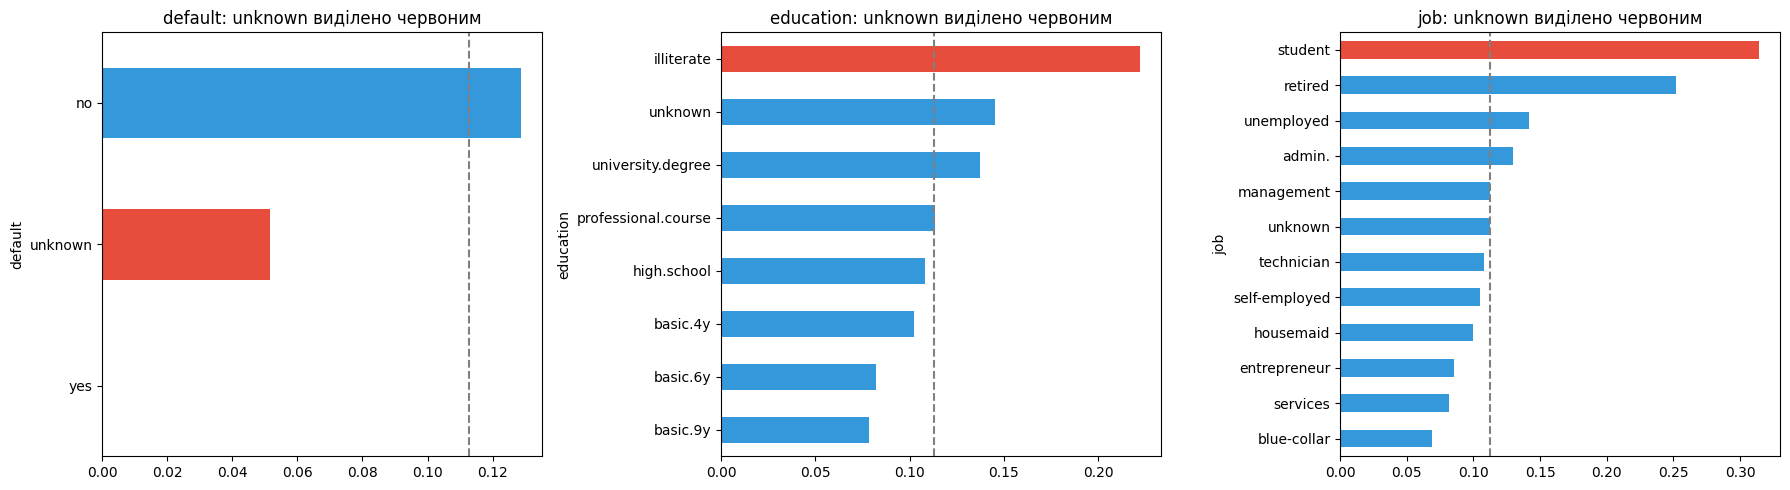

In [40]:
# ============================================
# Аналіз unknown значень
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
unknown_cols = ['default', 'education', 'job']

for i, col in enumerate(unknown_cols):
    stats = raw_dataset.groupby(col)['y_num'].mean()
    is_unknown = [c == 'unknown' for c in stats.index]
    colors = ['#e74c3c' if u else '#3498db' for u in is_unknown]
    stats.sort_values().plot(kind='barh', ax=axes[i], color=colors)
    axes[i].set_title(f'{col}: unknown виділено червоним', fontsize=12)
    axes[i].axvline(x=avg_rate, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

 **Висновок:**

 - default: 20.9% unknown — залишити як окрему категорію
 - education: 4.2% unknown — залишити як є
 - job, housing, loan: <2.5% — залишити як є

ВИСНОВКИ ПО КАТЕГОРІАЛЬНИХ ЗМІННИХ:

1. СИЛЬНІ ПРЕДИКТОРИ:
   - poutcome: success дає 65% конверсії (але лише 3.3% записів)
   - month: від 6% (may) до 50% (mar), великий розкид
   - contact: cellular (14.7%) значно краще telephone (5.2%)

2. ПОМІРНІ ПРЕДИКТОРИ:
   - job: student (31%) і retired (25%) виділяються
   - education: university degree (13.7%) vs basic (7-8%)

3. СЛАБКІ ПРЕДИКТОРИ:
   - housing, loan: ~11% для всіх категорій, майже не впливають
   - day_of_week: різниця мінімальна (10-12%)
   - marital: single трохи краще (14% vs 10%)

4. ДЛЯ ПРЕПРОЦЕСИНГУ:
   - job: можна згрупувати student+retired (висока конверсія)
   - education: об'єднати basic.4y + basic.6y + basic.9y → basic
   - month: можна згрупувати "високі" (mar,sep,oct,dec) vs "низькі"
   - default: "yes" лише 3 записи — об'єднати з unknown
   - housing, loan, day_of_week — залишити, але очікувати слабкий вплив

In [41]:
# Перевірка: чи "успішні" місяці — це просто інший економічний період?
month_macro = raw_dataset.groupby('month').agg({
    'y_num': 'mean',
    'emp.var.rate': 'mean',
    'euribor3m': 'mean',
    'nr.employed': 'mean',
    'cons.conf.idx': 'mean'
}).sort_values('y_num', ascending=False)

month_macro['y_num'] = month_macro['y_num'].map('{:.1%}'.format)
print(month_macro.round(2))

       y_num  emp.var.rate  euribor3m  nr.employed  cons.conf.idx
month                                                            
mar    50.5%         -1.80       1.16      5055.39         -42.65
dec    48.9%         -2.85       0.87      5031.90         -33.71
sep    44.9%         -2.18       0.83      4988.85         -33.89
oct    43.9%         -2.44       1.20      5018.82         -34.58
apr    20.5%         -1.80       1.36      5093.12         -46.27
aug    10.6%          0.75       4.30      5200.25         -35.60
jun    10.5%          0.69       4.26      5197.49         -41.58
nov    10.1%         -0.42       3.72      5173.03         -41.24
jul     9.0%          1.16       4.69      5214.08         -42.37
may     6.4%         -0.16       3.29      5149.52         -40.58


Бачимо, що "успішні" місяці (mar, dec, sep, oct) — конверсія 44–50% — усі мають emp.var.rate від -1.8 до -2.85, euribor3m від 0.83 до 1.36, nr.employed ~5000–5055. Це період економічного спаду: зайнятість падає, ставки низькі.
"Невдалі" місяці (may, jul, aug, jun) — конверсія 6–10% — emp.var.rate від +0.69 до +1.16, euribor3m від 3.29 до 4.69, nr.employed ~5150–5214. Це період економічного зростання.

Різниця разюча: euribor3m в "успішних" місяцях ~1%, в "невдалих" ~4%. Це не збіг, а прямий зв'язок.

**Що це означає для моделі:** month і макрозмінні значною мірою несуть одну й ту саму інформацію — "в який економічний період відбувся контакт". Тому в моделі вони будуть конкурувати між собою за feature importance.

Тож для лінійних моделей треба залишити щось одне: або макрозмінні (emp.var.rate, cons.conf.idx), або month. Макрозмінні краще, бо вони числові і містять точніший сигнал, ніж назва місяця.


In [42]:
# Чи відрізняється вік по типу контакту?
print(raw_dataset.groupby('contact')['age'].describe().round(1))

# Чи відрізняється кількість дзвінків по результату?
print(raw_dataset.groupby('poutcome')['campaign'].describe().round(1))

             count  mean   std   min   25%   50%   75%   max
contact                                                     
cellular  26144.00 40.00 11.00 17.00 32.00 38.00 47.00 98.00
telephone 15044.00 40.10  9.40 18.00 33.00 39.00 47.00 86.00
               count  mean  std  min  25%  50%  75%   max
poutcome                                                 
failure      4252.00  2.00 1.50 1.00 1.00 1.00 2.00 16.00
nonexistent 35563.00  2.70 2.90 1.00 1.00 2.00 3.00 56.00
success      1373.00  1.80 1.20 1.00 1.00 1.00 2.00  8.00


**contact vs age** — розподіл віку практично ідентичний для cellular і telephone (mean ~40, медіана 38–39, std ~10). Тобто тип контакту не пов'язаний з віком — це незалежні ознаки, і кожна несе свою інформацію. Різниця в конверсії (14.7% vs 5.2%) пояснюється саме каналом зв'язку, а не тим, що по телефону дзвонять старшим людям.


**poutcome vs campaign** — а тут є цікаве:

 - success: mean = 1.8 дзвінків, 75-й перцентиль = 2. Клієнтам з попереднім успіхом дзвонять менше і вони швидко погоджуються.
 - failure: mean = 2.0, теж небагато, але max = 16.
 - nonexistent: mean = 2.7, max = 56 — саме в цій групі банк "дотискує" клієнтів багаторазовими дзвінками, але ефект слабкий.

Це логічно: "теплий" клієнт (success) конвертується з 1–2 дзвінків, а "холодного" (nonexistent) можна набирати 56 разів і все одно не переконати.

Тобто **poutcome і campaign частково пов'язані** — банк інтуїтивно адаптує кількість дзвінків під тип клієнта. Але campaign все одно несе додаткову інформацію, бо навіть всередині nonexistent ті, кому дзвонили менше, конвертуються трохи краще.

Базуючись на проведеному EDA, ось план препроцесингу, який треба зробити, враховуючи те, що будемо працювати з лінійними та нелінійними моделями:

**Повний план препроцесингу**

**Спільні кроки (для всіх моделей)**

1. Видалення змінних:

duration — data leakage, відома лише після дзвінка

2. Трансформація pdays:

Створити was_contacted_before = (pdays != 999)
В оригінальному pdays замінити 999 → -1 (щоб відділити "не було контакту" від реальних значень)

3. Unknown значення — залишити як окрему категорію:

default (20.9% unknown — має свій патерн конверсії 5.2%)
education (4.2%), job (0.8%), marital (0.2%), housing (2.4%), loan (2.4%) — залишити як є

4. Групування категорій:

education: basic.4y + basic.6y + basic.9y → basic
default: yes (3 записи) + unknown → unknown_or_yes, оскільки обидві групи мають низьку конверсію

5. Розбиття на train/test:

Зробити до будь-якого кодування і скейлінгу, щоб уникнути data leakage
Стратифікований split (stratify=y), бо датасет незбалансований (88.7% / 11.3%)


Для лінійних моделей (Logistic Regression, kNN)
1. Видалення/відбір макрозмінних:

Залишити лише emp.var.rate і cons.conf.idx (за результатами VIF-аналізу)
Видалити nr.employed, cons.price.idx, euribor3m

2. Нова ознака для віку:

Додати age_squared = age², щоб вловити нелінійний J-подібний зв'язок з y

3. Кодування категоріальних змінних:

One-Hot Encoding для всіх категоріальних (job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome)
Використати drop_first=True, щоб уникнути мультиколінеарності між dummy-змінними

4. Масштабування числових змінних:

StandardScaler для Logistic Regression (age, age_squared, campaign, pdays, previous, emp.var.rate, cons.conf.idx)
Для kNN — обов'язково, бо kNN чутливий до масштабу

5. Обробка outliers:

campaign: обрізати на 95-му перцентилі (cap) або log-трансформація
Для kNN це особливо важливо, бо outliers спотворюють відстані


**Для нелінійних моделей (Decision Tree, Boosting)**

1. Макрозмінні:

Залишити всі 5 — дерева не чутливі до мультиколінеарності

2. Вік:

Залишити просто age без додаткових ознак — дерева самі знайдуть нелінійність через сплітування

3. Кодування категоріальних змінних:

Варіант А: OrdinalEncoder / LabelEncoder — бустинг (LightGBM, CatBoost) добре працює з порядковим кодуванням

Варіант B: Для sklearn Decision Tree і XGBoost — One-Hot Encoding або OrdinalEncoder

4. Масштабування:

Не потрібне — дерева та бустинг інваріантні до масштабу

5. Обробка outliers:

Не потрібна — дерева нечутливі до outliers, вони просто створять окремий сплітування


**Робота з дисбалансом класів**

Це стосується обох типів моделей. Датасет сильно незбалансований (88.7% / 11.3%), тому варто спробувати:

class_weight='balanced' для Logistic Regression і Decision Tree
scale_pos_weight для XGBoost / LightGBM

Або SMOTE на тренувальному наборі (тільки на train)